In [ ]:
!git clone https://github.com/ayeshanafees48/Tools-and-Tech-70189383
%cd Tools-and-Tech-70189383

Cloning into 'Tools-and-Tech-70189383'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 20 (delta 5), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (20/20), 250.09 KiB | 6.95 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/Tools-and-Tech-70189383/Tools-and-Tech-70189383


In [ ]:
!ls

CA1.csv  Encoder.py  Graph_Visualize.py  Scalar.py


In [ ]:
import warnings
warnings.filterwarnings("ignore")

## **PREPROCESSING**

In [ ]:
#Imports
from Encoder import Encoder
import pandas as pd
from Scalar import Scaler
import numpy as np
import warnings
# Load Dataset
df = pd.read_csv("CA1.csv")
print("---------------------------------------------")
print("Original Dataset Shape:", df.shape)
print("---------------------------------------------")


---------------------------------------------
Original Dataset Shape: (12330, 18)
---------------------------------------------


# **DATA CLEANING**

# **Checking Missing Values**

In [ ]:
# Check missing values
print("Missing Values in Each Column:")
print(df.isnull().sum())
# Percentage of missing values
print("\nMissing Values Percentage:")
print((df.isnull().sum() / len(df)) * 100)

Missing Values in Each Column:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Missing Values Percentage:
Administrative             0.0
Administrative_Duration    0.0
Informational              0.0
Informational_Duration     0.0
ProductRelated             0.0
ProductRelated_Duration    0.0
BounceRates                0.0
ExitRates                  0.0
PageValues                 0.0
SpecialDay                 0.0
Month                      0.0
OperatingSystems           0.0
Browser                    0.0
Reg

# **Checking Duplicates**

In [ ]:
duplicate_Count = df.duplicated().sum()
print("Duplicate Count (before):", duplicate_Count)
if duplicate_Count > 0:
    duplicate_Rows = df[df.duplicated(keep=False)]
    print("\nDuplicate Rows are:")
    print(duplicate_Rows)
    df = df.drop_duplicates()
    new_count = df.duplicated().sum()
    print("\nDuplicates removed successfully!")
    print("Duplicate Count (after):", new_count)
    print("New shape of dataset:", df.shape)
else:
    print("\nThere is no duplicate in dataset (even after cleaning)")

Duplicate Count (before): 125

Duplicate Rows are:
       Administrative  Administrative_Duration  Informational  \
85                  0                      0.0              0   
132                 0                      0.0              0   
158                 0                      0.0              0   
159                 0                      0.0              0   
178                 0                      0.0              0   
...               ...                      ...            ...   
11934               0                      0.0              0   
11938               0                      0.0              0   
12159               0                      0.0              0   
12180               0                      0.0              0   
12185               0                      0.0              0   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
85                        0.0               1                      0.0   
132                 

# **Checking Typo and Spelling Errors**

In [ ]:
valid_months = ['jan','feb','mar','apr','may','june','jul','aug','sep','oct','nov','dec']
df['Month'] = df['Month'].str.lower().str.strip()
invalid_months = df[~df['Month'].isin(valid_months)]['Month'].unique()
print("Invalid Month Values:", invalid_months)
valid_types = ['returning_visitor', 'new_visitor', 'other']
df['VisitorType'] = df['VisitorType'].str.lower().str.strip()
invalid_types = df[~df['VisitorType'].isin(valid_types)]['VisitorType'].unique()
print("Invalid VisitorType Values:", invalid_types)

Invalid Month Values: []
Invalid VisitorType Values: []


# **Handling Outliers**

Administrative Outliers: 404
Administrative_Duration Outliers: 1149
Informational Outliers: 2631
Informational_Duration Outliers: 2405
ProductRelated Outliers: 1007
ProductRelated_Duration Outliers: 951
BounceRates Outliers: 1428
ExitRates Outliers: 1325
PageValues Outliers: 2730
SpecialDay Outliers: 1249

Outlier Type Detection
Administrative --> Skewness: 1.95 --> Right Skewed (Positive Skew)


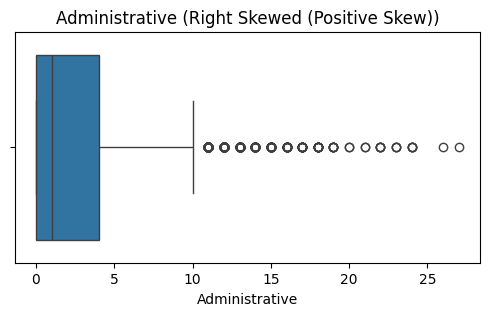

Administrative_Duration --> Skewness: 5.59 --> Right Skewed (Positive Skew)


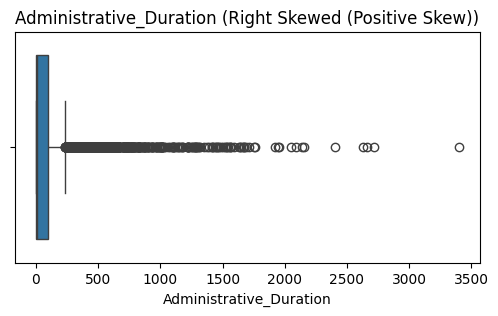

Informational --> Skewness: 4.01 --> Right Skewed (Positive Skew)


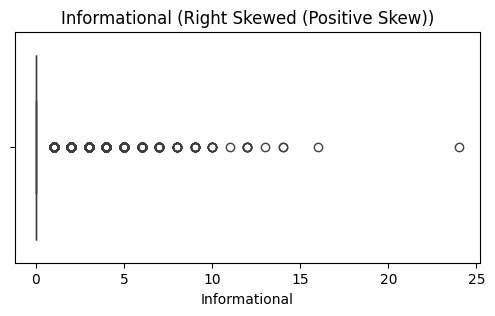

Informational_Duration --> Skewness: 7.54 --> Right Skewed (Positive Skew)


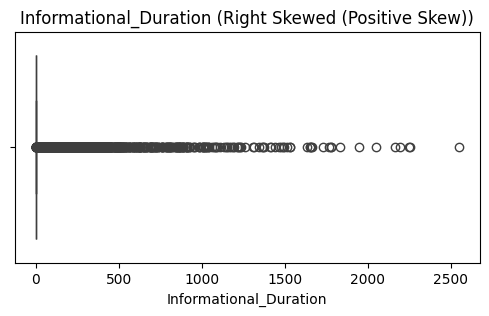

ProductRelated --> Skewness: 4.33 --> Right Skewed (Positive Skew)


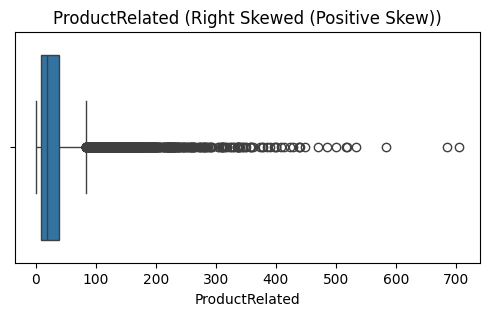

ProductRelated_Duration --> Skewness: 7.25 --> Right Skewed (Positive Skew)


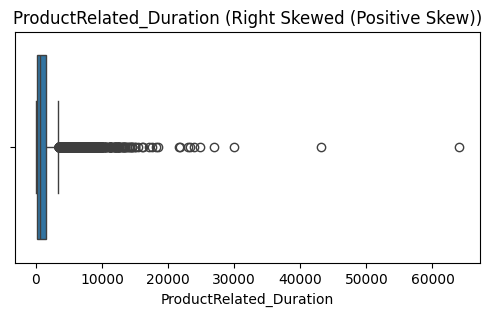

BounceRates --> Skewness: 3.16 --> Right Skewed (Positive Skew)


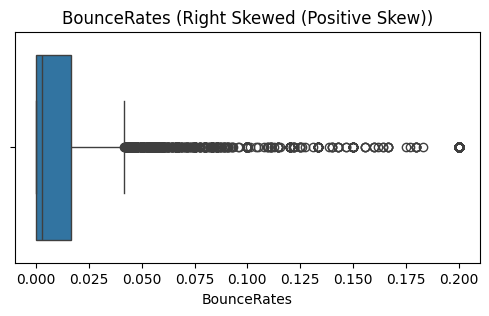

ExitRates --> Skewness: 2.23 --> Right Skewed (Positive Skew)


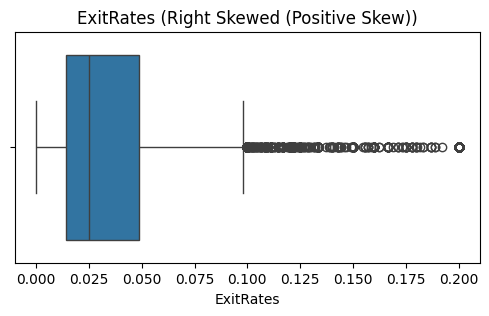

PageValues --> Skewness: 6.35 --> Right Skewed (Positive Skew)


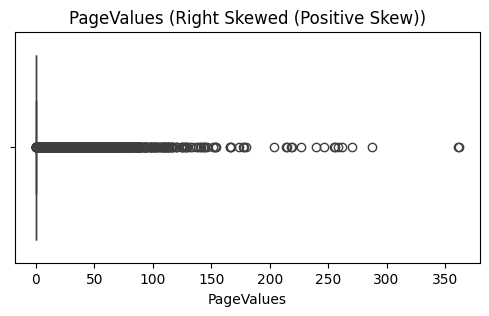

SpecialDay --> Skewness: 3.29 --> Right Skewed (Positive Skew)


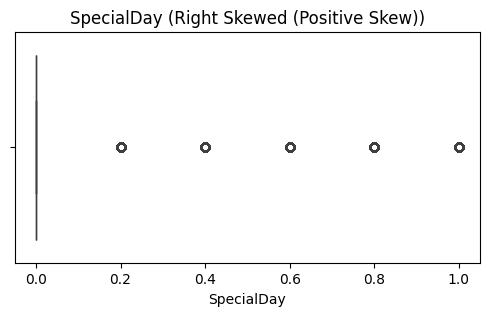

In [ ]:
import numpy as np
numerical_cols = [
"Administrative",
"Administrative_Duration",
"Informational",
"Informational_Duration",
"ProductRelated",
"ProductRelated_Duration",
"BounceRates",
"ExitRates",
"PageValues",
"SpecialDay"
]
for col in numerical_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  outliers = df[(df[col] < lower) | (df[col] > upper)]
  print(col, "Outliers:", len(outliers))
import matplotlib.pyplot as plt
import seaborn as sns
print("\nOutlier Type Detection")
for col in numerical_cols:
    skew_val = df[col].skew()
    if skew_val > 0.5:
        skew_type = "Right Skewed (Positive Skew)"
    elif skew_val < -0.5:
        skew_type = "Left Skewed (Negative Skew)"
    else:
        skew_type = "Approximately Symmetric"
    print(f"{col} --> Skewness: {skew_val:.2f} --> {skew_type}")
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"{col} ({skew_type})")
    plt.show()

**As the outliers are Right Skewed so there is a need to apply Log Transformation**

In [ ]:
transform_Columns = ["Administrative" , "Informational_Duration" , "Informational" , "ProductRelated" , "ProductRelated_Duration" , "BounceRates" , "ExitRates" , "PageValues" , "SpecialDay"]
for transformation in transform_Columns:
  df[transformation] = np.log1p(df[transformation])
for col in numerical_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  outliers = df[(df[col] < lower) | (df[col] > upper)]
  print(col, "Outliers After Log Transformation:", len(outliers))

Administrative Outliers After Log Transformation: 0
Administrative_Duration Outliers After Log Transformation: 1149
Informational Outliers After Log Transformation: 2631
Informational_Duration Outliers After Log Transformation: 2405
ProductRelated Outliers After Log Transformation: 30
ProductRelated_Duration Outliers After Log Transformation: 702
BounceRates Outliers After Log Transformation: 1420
ExitRates Outliers After Log Transformation: 980
PageValues Outliers After Log Transformation: 2730
SpecialDay Outliers After Log Transformation: 1249


# **Apply Capping to reach to the zero**

In [ ]:
numeric_Columns = ["Administrative_Duration", "Informational" , "Informational_Duration" , "ProductRelated" , "ProductRelated_Duration" , "BounceRates" , "ExitRates" , "PageValues" , "SpecialDay"]
for int_column in numeric_Columns:
  qunatile_1 = df[int_column].quantile(0.25)
  quantile_3 = df[int_column].quantile(0.75)
  calculated_IQR = quantile_3 - qunatile_1
  lower_Bound = qunatile_1 - (1.5 * calculated_IQR)
  upper_Bound = quantile_3 + (1.5 * calculated_IQR)
  df[int_column] = np.where(df[int_column] < lower_Bound , lower_Bound , df[int_column])
  df[int_column] = np.where(df[int_column] > upper_Bound , upper_Bound , df[int_column])
for col in numerical_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  outliers = df[(df[col] < lower) | (df[col] > upper)]
  print(col, "Outliers After Capping:", len(outliers))


Administrative Outliers After Capping: 0
Administrative_Duration Outliers After Capping: 0
Informational Outliers After Capping: 0
Informational_Duration Outliers After Capping: 0
ProductRelated Outliers After Capping: 0
ProductRelated_Duration Outliers After Capping: 0
BounceRates Outliers After Capping: 0
ExitRates Outliers After Capping: 0
PageValues Outliers After Capping: 0
SpecialDay Outliers After Capping: 0


# **FEATURE ENGINNERING & DATA TRANSFORMATION**

In [ ]:
# 1. Total Time Spent
df['Total_Time'] = ( df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration'] )
# 2. Total Pages Visited
df['Total_Pages'] = ( df['Administrative'] + df['Informational'] + df['ProductRelated'] )
# 3. Engagement Ratio
df['Engagement_Ratio'] = df['Total_Time'] / (df['Total_Pages'] + 1)
# 4. Value Per Page
df['Value_Per_Page'] = df['PageValues'] / (df['ProductRelated'] + 1)
print("\nNew Features Added Successfully")
print(df[['Total_Time', 'Total_Pages', 'Engagement_Ratio', 'Value_Per_Page']].head())
df.info()


New Features Added Successfully
   Total_Time  Total_Pages  Engagement_Ratio  Value_Per_Page
0    2.221821     0.693147          1.312243             0.0
1    4.174387     1.098612          1.989118             0.0
2    2.221821     0.693147          1.312243             0.0
3    2.221821     1.098612          1.058709             0.0
4    6.443336     2.397895          1.896273             0.0
<class 'pandas.core.frame.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  float64
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  float64
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  float64
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRa

# **ADVANCE FEATURE ENGINNERING & INTERACTION**


*   Polynomial Features




In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly_cols = [
    'Total_Time',
    'Total_Pages',
    'Engagement_Ratio',
    'Value_Per_Page'
]
# Polynomial Feature Object
poly = PolynomialFeatures(degree=2, include_bias=False)
# Create Features
poly_features = poly.fit_transform(df[poly_cols])
# Feature Names
poly_feature_names = poly.get_feature_names_out(poly_cols)
# Convert to DataFrame
poly_df = pd.DataFrame(poly_features, columns=poly_feature_names)
# Remove original duplicate columns
poly_df = poly_df.drop(columns=poly_cols)
# Merge with original dataset
df = pd.concat([df.reset_index(drop=True), poly_df.reset_index(drop=True)], axis=1)
print("\nPolynomial Features Added Successfully")
df.info()


Polynomial Features Added Successfully
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12205 entries, 0 to 12204
Data columns (total 32 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Administrative                   12205 non-null  float64
 1   Administrative_Duration          12205 non-null  float64
 2   Informational                    12205 non-null  float64
 3   Informational_Duration           12205 non-null  float64
 4   ProductRelated                   12205 non-null  float64
 5   ProductRelated_Duration          12205 non-null  float64
 6   BounceRates                      12205 non-null  float64
 7   ExitRates                        12205 non-null  float64
 8   PageValues                       12205 non-null  float64
 9   SpecialDay                       12205 non-null  float64
 10  Month                            12205 non-null  object 
 11  OperatingSystems                 12205 n

# **BINNING**

In [ ]:
print(df['ProductRelated_Duration'].min())
print(df['ProductRelated_Duration'].max())
print(df['PageValues'].min())
print(df['PageValues'].max())

2.2218206879895015
10.344587277519706
0.0
0.0


In [ ]:
# ProductRelated_Duration
df['ProductRelated_Duration_Bin'] = pd.cut(
    df['ProductRelated_Duration'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)
# BounceRates
df['BounceRates_Bin'] = pd.cut(
    df['BounceRates'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

print(df[['ProductRelated_Duration_Bin',
          'BounceRates_Bin']].head())

  ProductRelated_Duration_Bin BounceRates_Bin
0                         Low            High
1                         Low             Low
2                         Low            High
3                         Low            High
4                      Medium          Medium


# **Feature Transformation: Scaling and Encoding**

In [ ]:
from Encoder import Encoder
from Scalar import Scaler
import numpy as np
import warnings
# -------------------------------
# Encoding
# -------------------------------
binary_cols = ["Weekend" , "Revenue"]
nominal_cols = ["Month", "VisitorType"]
ordinal_cols = ["Browser" , "Region" , "OperatingSystems" , "TrafficType" , 'ProductRelated_Duration_Bin', 'BounceRates_Bin']
encoder = Encoder()
# Apply encoding on full dataset
X = encoder.label_encode(df, binary_cols)
X = encoder.onehot_encode(df, nominal_cols)
X = encoder.label_encode(df, ordinal_cols)
print("---------------------------------------------")
print("After Encoding Shape:", X.shape)
print("---------------------------------------------")
# -------------------------------
# Scaling
# -------------------------------
numerical_cols = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
    "Total_Time",
    "Total_Pages",
    "Engagement_Ratio",
    "Value_Per_Page"
]
scaler = Scaler(method="standard")
# Fit + Transform on full dataset
X = scaler.fit_transform(df, numerical_cols)
X.describe()
print("---------------------------------------------")
print("After Scaling Shape:", df.shape)
print("---------------------------------------------")
X.head()

---------------------------------------------
After Encoding Shape: (12205, 34)
---------------------------------------------
---------------------------------------------
After Scaling Shape: (12205, 34)
---------------------------------------------


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Total_Time Engagement_Ratio,Total_Time Value_Per_Page,Total_Pages^2,Total_Pages Engagement_Ratio,Total_Pages Value_Per_Page,Engagement_Ratio^2,Engagement_Ratio Value_Per_Page,Value_Per_Page^2,ProductRelated_Duration_Bin,BounceRates_Bin
0,-0.932479,-0.721911,0.0,0.0,-2.001350,-2.389594,2.147202,2.222963,0.0,0.0,...,2.915569,0.0,0.480453,0.909578,0.0,1.721982,0.0,0.0,Low,High
1,-0.932479,-0.721911,0.0,0.0,-1.634840,-1.198896,-0.728527,2.153223,0.0,0.0,...,8.303348,0.0,1.206949,2.185269,0.0,3.956590,0.0,0.0,Low,Low
2,-0.932479,-0.721911,0.0,0.0,-2.001350,-2.389594,2.147202,2.222963,0.0,0.0,...,2.915569,0.0,0.480453,0.909578,0.0,1.721982,0.0,0.0,Low,High
3,-0.932479,-0.721911,0.0,0.0,-1.634840,-2.389594,2.147202,2.222963,0.0,0.0,...,2.352263,0.0,1.206949,1.163111,0.0,1.120866,0.0,0.0,Low,High
4,-0.932479,-0.721911,0.0,0.0,-0.460384,0.184735,0.649559,0.502485,0.0,0.0,...,12.218322,0.0,5.749902,4.547063,0.0,3.595850,0.0,0.0,Medium,Medium


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12205 entries, 0 to 12204
Data columns (total 42 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Administrative                   12205 non-null  float64
 1   Administrative_Duration          12205 non-null  float64
 2   Informational                    12205 non-null  float64
 3   Informational_Duration           12205 non-null  float64
 4   ProductRelated                   12205 non-null  float64
 5   ProductRelated_Duration          12205 non-null  float64
 6   BounceRates                      12205 non-null  float64
 7   ExitRates                        12205 non-null  float64
 8   PageValues                       12205 non-null  float64
 9   SpecialDay                       12205 non-null  float64
 10  OperatingSystems                 12205 non-null  int64  
 11  Browser                          12205 non-null  int64  
 12  Region            

# **STATISTICAL ANALYSIS**


In [ ]:
# -------------------------------
# Statistical Analysis
# -------------------------------
numerical_cols = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]
# Mean
print("Mean:")
print(df[numerical_cols].mean())
# Median
print("\nMedian:")
print(df[numerical_cols].median())
# Mode
print("\nMode:")
print(df[numerical_cols].mode().iloc[0])
# Standard Deviation
print("\nStandard Deviation:")
print(df[numerical_cols].std())
# Variance
print("\nVariance:")
print(df[numerical_cols].var())
# Minimum Values
print("\nMinimum Values:")
print(df[numerical_cols].min())
# Maximum Values
print("\nMaximum Values:")
print(df[numerical_cols].max())
# Complete Statistical Summary
print("\nStatistical Summary:")
print(df[numerical_cols].describe())

Mean:
Administrative              0.805126
Administrative_Duration    57.899459
Informational               0.000000
Informational_Duration      0.000000
ProductRelated              2.907211
ProductRelated_Duration     6.140398
BounceRates                 0.010469
ExitRates                   0.034629
PageValues                  0.000000
SpecialDay                  0.000000
dtype: float64

Median:
Administrative             0.693147
Administrative_Duration    9.000000
Informational              0.000000
Informational_Duration     0.000000
ProductRelated             2.944439
ProductRelated_Duration    6.413365
BounceRates                0.002894
ExitRates                  0.024693
PageValues                 0.000000
SpecialDay                 0.000000
dtype: float64

Mode:
Administrative             0.000000
Administrative_Duration    0.000000
Informational              0.000000
Informational_Duration     0.000000
ProductRelated             0.693147
ProductRelated_Duration    2.221821
Bo

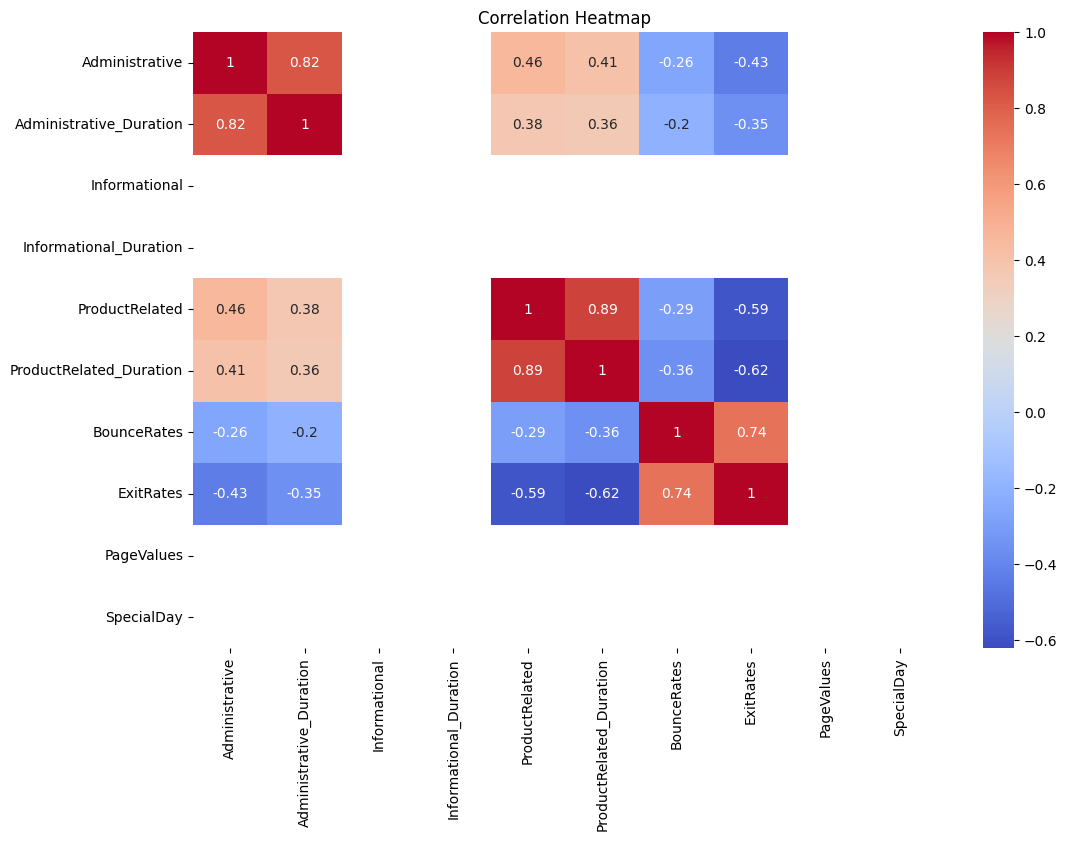

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()